# 04 — 控制流：條件邊、迴圈、`Command`、`Send`

**這份要學什麼**
- 條件邊 `add_conditional_edges`：怎麼依狀態決定下一步
- `Command`：一次做完「改狀態」+「決定下一步」
- `Send`：同一個 node 對一批資料平行處理
- `recursion_limit`：防止邏輯寫錯造成無限迴圈

> 不需要 API key，一樣先不碰 LLM，專注在「圖怎麼分支/迴圈」這件事本身。

`01_langchain_basics.ipynb` 提過：LCEL chain 是一直線，想要分支或迴圈會很痛苦。`03_langgraph_core.ipynb` 裡的走廊（edge）都是固定的——做完 A 一定去 B。這份 notebook 教三個新招式：

- **保全站崗的走廊（條件邊）**：走到走廊口，保全看一眼工作單，決定放你去哪一間房——也可能放你「繞回原本那間房再走一次」，這就是迴圈
- **一次動作做兩件事（`Command`）**：工作站自己一邊改工作單、一邊決定下一站去哪，不用另外派保全
- **同一站分身處理一批資料（`Send`）**：讓同一個工作站同時對一批資料各自跑一次，結果再彙總回來

先看一張迴圈長什麼樣：

```
START ──▶ [ 工作站 ] ──▶ 保全站崗
               ▲             │
               │  還沒做完    │  做完了
               └─────────────┤
                              ▼
                             END
```

## 條件邊（`add_conditional_edges`）：保全站崗，依工作單決定放你去哪

`add_conditional_edges(source, path_fn)` 裡的 `path_fn` 就是那個保全：拿到目前的 State（工作單），回傳「下一站的名字」（或 `"__end__"` 表示可以下班了）。

如果保全回傳的名字剛好跟 `source` 自己一樣，工作單就會被送回原本那站再做一次——這就是 LangGraph 表達「迴圈」的方式，不需要另外寫一個「while 迴圈」的節點。下面的例子：`count` 每次 +1，保全檢查「還沒數到 3」就繞回 `increment` 再做一次，數到 3 才放行去 `__end__`。

```
START ──▶ [ increment ] ──count<3──▶ 繞回 increment（迴圈）
                │
                └──count>=3──▶ END
```

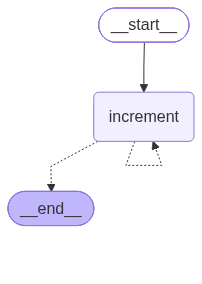

{'count': 3}


In [1]:
import sys
from typing import Literal, TypedDict

sys.path.insert(0, ".")
from langgraph.graph import END, START, StateGraph

from _graph_viz import show_graph


class CounterState(TypedDict):
    count: int


def increment(state: CounterState) -> dict:
    return {"count": state["count"] + 1}


def route(state: CounterState) -> Literal["increment", "__end__"]:
    # 回傳跟 source 節點同名 -> 迴圈；回傳 "__end__" -> 結束
    return "increment" if state["count"] < 3 else "__end__"


builder = StateGraph(CounterState)
builder.add_node("increment", increment)
builder.add_edge(START, "increment")
builder.add_conditional_edges("increment", route)
loop_graph = builder.compile()

show_graph(loop_graph)
print(loop_graph.invoke({"count": 0}))  # count 會一路加到 3 才停

## `Command`：一次動作，同時「改工作單」＋「決定下一站」

用條件邊的寫法，要另外定義一個 `route()` 函式來決定下一站——如果「決定下一步」的邏輯本來就得看工作站剛執行完的結果（例如呼叫 LLM 之後，看它想不想用工具），把邏輯拆成兩個函式反而繞遠路。

`Command(update=..., goto=...)` 讓工作站自己一次講完兩件事：狀態怎麼改＋去哪一站。就像填完一張申請表，同時自己蓋章決定要送去哪個窗口，不用再麻煩另一個人分流。後面 `09_langgraph_multi_agent.ipynb` 的 supervisor 模式會大量用到這種寫法。

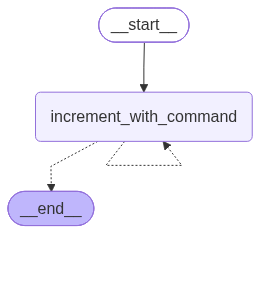

{'count': 3}


In [2]:
from langgraph.types import Command


def increment_with_command(state: CounterState) -> Command[Literal["increment_with_command", "__end__"]]:
    new_count = state["count"] + 1
    next_node = "increment_with_command" if new_count < 3 else END
    return Command(update={"count": new_count}, goto=next_node)


cmd_builder = StateGraph(CounterState)
cmd_builder.add_node("increment_with_command", increment_with_command)
cmd_builder.add_edge(START, "increment_with_command")
cmd_graph = cmd_builder.compile()

show_graph(cmd_graph)
print(cmd_graph.invoke({"count": 0}))

留意上面完全沒寫 `add_edge` / `add_conditional_edges` 接到下一站——`Command` 的 `goto` 本身就是那條走廊。型別標注 `Command[Literal[...]]` 只是讓 LangGraph 畫圖時知道這個工作站可能會去哪幾個地方，不影響實際執行結果。

## `Send`：同一個工作站，對一批資料各自平行處理一次

假設要對一個列表裡的每一項各自處理一次（例如「幫每個主題各寫一段摘要」）——單一 State 沒辦法表達「同一個工作站要平行跑 N 次、每次帶不同輸入」這件事。

`Send(工作站名字, 這次的輸入)` 就是為此設計的：從一個保全（conditional edge）回傳一組 `Send`，LangGraph 會對每個 `Send` 各自呼叫一次目標工作站，結果再依 reducer 合併回主工作單（這裡用 `operator.add`，也就是把多份結果的列表直接串接起來）。

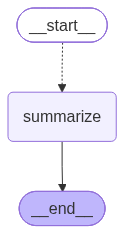

{'topics': ['LangChain', 'LangGraph', 'uv'], 'summaries': ['summary of LangChain', 'summary of LangGraph', 'summary of uv']}


In [3]:
import operator
from typing import Annotated

from langgraph.types import Send


class FanState(TypedDict):
    topics: list[str]
    summaries: Annotated[list[str], operator.add]


class SubState(TypedDict):
    topic: str


def fanout(state: FanState) -> list[Send]:
    return [Send("summarize", {"topic": t}) for t in state["topics"]]


def summarize(state: SubState) -> dict:
    return {"summaries": [f"summary of {state['topic']}"]}


fan_builder = StateGraph(FanState)
fan_builder.add_node("summarize", summarize)
fan_builder.add_conditional_edges(START, fanout, ["summarize"])
fan_builder.add_edge("summarize", END)
fan_graph = fan_builder.compile()

show_graph(fan_graph)
print(fan_graph.invoke({"topics": ["LangChain", "LangGraph", "uv"], "summaries": []}))

## 逛太久會被請出去：`recursion_limit`

條件邊可以讓工作站一直繞圈圈——正常情況下繞到某個條件就會停，但如果邏輯寫錯（例如
忘記讓計數器遞增），圖會無限迴圈下去，永遠等不到結果。LangGraph 有一個內建的保險絲：
`recursion_limit`，繞超過這個步數還沒結束，直接丟例外把你踢出去，而不是讓程式卡死。

下面故意寫一個「忘記讓 count 變化」的迴圈，示範這個保險絲怎麼發作。

In [4]:
from langgraph.errors import GraphRecursionError


def buggy_increment(state: CounterState) -> dict:
    return {"count": state["count"]}  # bug：忘記 +1，count 永遠不會變


buggy_builder = StateGraph(CounterState)
buggy_builder.add_node("increment", buggy_increment)  # 節點名稱要跟 route() 回傳的字串對上
buggy_builder.add_edge(START, "increment")
buggy_builder.add_conditional_edges("increment", route)  # route 檢查 count < 3，這裡永遠是 True
buggy_graph = buggy_builder.compile()

try:
    buggy_graph.invoke({"count": 0}, {"recursion_limit": 5})
except GraphRecursionError as e:
    print(f"{type(e).__name__}: 在繞死之前先被保險絲擋下來了")

GraphRecursionError: 在繞死之前先被保險絲擋下來了


## 小結：三種控制流工具怎麼選

| 工具 | 用途 |
|---|---|
| `add_conditional_edges`（保全站崗） | 「決定下一步」跟「更新狀態」邏輯上分開比較清楚時用 |
| `Command(update=, goto=)`（一次動作兩件事） | 工作站執行完立刻知道要去哪，兩件事寫在一起更直覺（尤其是 LLM 路由決策） |
| `Send(node, state)`（分批平行處理） | 同一個工作站要對「一批」資料各自平行處理，結果再彙總 |

下一份：`05_langgraph_tools_and_agent.ipynb`，把 LLM 接進工作站裡，正式做出一個會用工具的 agent——你會發現「LLM 決定要不要再查一次」其實就是這份學到的迴圈，只是繞回去的原因換成了「還沒拿到工具結果」。